# 4 - Policy Gradient Method (REINFORCE)

## Problem Definition

A drone delivery company wants to train drones directly through policy optimization

In [1]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

In [2]:
# 1. Define Policy Network (Parameterized Policy pi_theta)
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim, action_dim, hidden_dim=128):
        super(PolicyNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim),
            nn.Softmax(dim=-1),  # Outputs action probabilities
        )

    def forward(self, state):
        return self.net(state)


# 2. REINFORCE Algorithm with optional Reward Normalization
def train_reinforce(
    env_name="CartPole-v1", episodes=600, lr=1e-3, gamma=0.99, normalize_returns=True
):
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    policy = PolicyNetwork(state_dim, action_dim)
    optimizer = optim.Adam(policy.parameters(), lr=lr)

    rewards_history = []

    for ep in range(episodes):
        state, _ = env.reset()
        log_probs = []
        rewards = []
        done = False

        # Generate a full episode trajectory
        while not done:
            state_tensor = torch.FloatTensor(state)
            action_probs = policy(state_tensor)
            dist = Categorical(action_probs)

            # Stochastic action sampling
            action = dist.sample()
            log_prob = dist.log_prob(action)

            next_state, reward, terminated, truncated, _ = env.step(action.item())
            done = terminated or truncated

            log_probs.append(log_prob)
            rewards.append(reward)
            state = next_state

        rewards_history.append(sum(rewards))

        # Compute discounted returns G_t = sum(gamma^k * R_{t+k+1})
        returns = []
        G = 0
        for r in reversed(rewards):
            G = r + gamma * G
            returns.insert(0, G)

        returns = torch.tensor(returns, dtype=torch.float32)

        # Variance reduction: Reward/Return Normalization
        if normalize_returns and len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)

        # Policy Gradient loss: - sum(log_prob * G_t)
        policy_loss = []
        for log_prob, G_t in zip(log_probs, returns):
            policy_loss.append(-log_prob * G_t)

        optimizer.zero_grad()
        policy_loss = torch.stack(policy_loss).sum()
        policy_loss.backward()
        optimizer.step()

    env.close()
    return rewards_history

Training: Normalized Returns...
Training: Unnormalized Returns...
Training: High LR (1e-2)...
Training: Low LR (1e-4)...


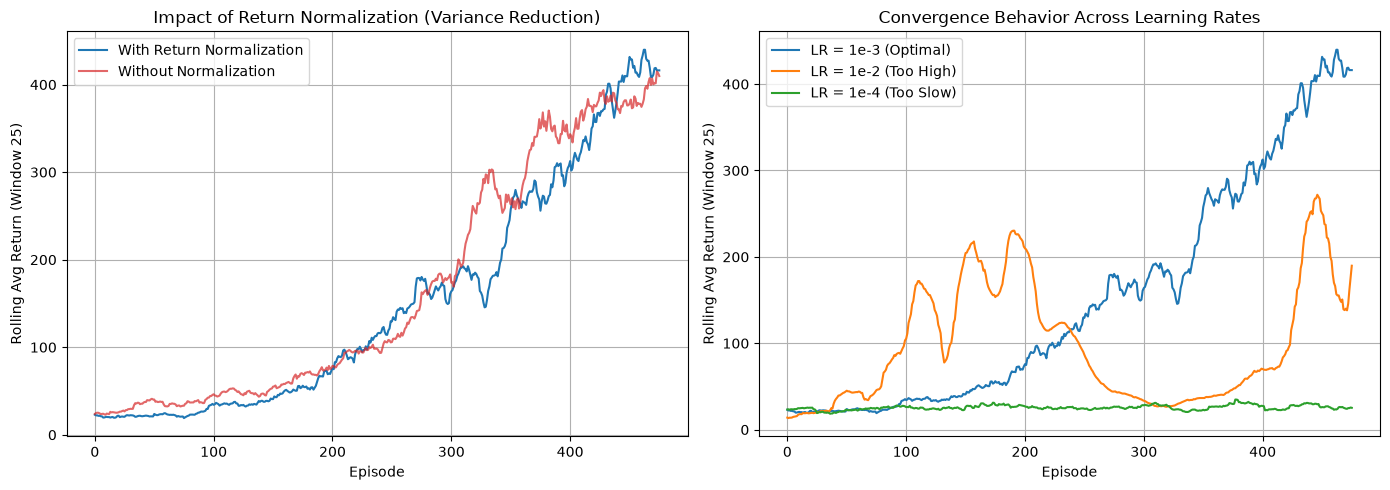

In [3]:
episodes = 500
window = 25

# 1. Compare Normalized vs. Unnormalized Returns (Variance Reduction)
print("Training: Normalized Returns...")
rewards_norm = train_reinforce(episodes=episodes, lr=1e-3, normalize_returns=True)

print("Training: Unnormalized Returns...")
rewards_unnorm = train_reinforce(episodes=episodes, lr=1e-3, normalize_returns=False)

# 2. Compare Different Learning Rates
print("Training: High LR (1e-2)...")
rewards_lr_high = train_reinforce(episodes=episodes, lr=1e-2, normalize_returns=True)

print("Training: Low LR (1e-4)...")
rewards_lr_low = train_reinforce(episodes=episodes, lr=1e-4, normalize_returns=True)


# Helper function to compute rolling averages
def moving_average(data, w):
    return np.convolve(data, np.ones(w) / w, mode="valid")


# Plot Results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Normalization Impact
axes[0].plot(
    moving_average(rewards_norm, window),
    label="With Return Normalization",
    color="tab:blue",
)
axes[0].plot(
    moving_average(rewards_unnorm, window),
    label="Without Normalization",
    color="tab:red",
    alpha=0.7,
)
axes[0].set_title("Impact of Return Normalization (Variance Reduction)")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel(f"Rolling Avg Return (Window {window})")
axes[0].legend()
axes[0].grid(True)

# Plot 2: Learning Rate Comparison
axes[1].plot(
    moving_average(rewards_norm, window), label="LR = 1e-3 (Optimal)", color="tab:blue"
)
axes[1].plot(
    moving_average(rewards_lr_high, window),
    label="LR = 1e-2 (Too High)",
    color="tab:orange",
)
axes[1].plot(
    moving_average(rewards_lr_low, window),
    label="LR = 1e-4 (Too Slow)",
    color="tab:green",
)
axes[1].set_title("Convergence Behavior Across Learning Rates")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel(f"Rolling Avg Return (Window {window})")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

## Performance Analysis & Conclusion

### 1. Impact of Return Normalization (Figure 1)
* **Variance Reduction:** In REINFORCE, Monte Carlo rollouts produce high variance in the trajectory return $G_t$. Normalizing the discounted returns ($G_t \leftarrow \frac{G_t - \mu}{\sigma + \epsilon}$) centers the batch of returns around zero, ensuring that actions that outperform the episode's average are reinforced while below-average actions are penalized
* **Convergence Trajectory:** Both normalized and unnormalized methods reach high average returns ($> 400$) by episode 450. However, the normalized formulation yields steadier parameter updates and guards against exploding gradients when trajectories become longer

### 2. Convergence Behavior Across Learning Rates (Figure 2)
* **Optimal Learning Rate ($\alpha = 10^{-3}$):** Follows a textbook policy improvement curve. It smoothly scales up from an average return of $\approx 25$ to over $400$ by episode 450, striking the balance between stability and speed of gradient ascent
* **High Learning Rate ($\alpha = 10^{-2}$):** Displays severe oscillation and policy instability. It quickly surges up to $\approx 230$ around episode 180, but then collapses down to $\approx 30$ due to overshooting the optimal parameter region (catastrophic policy collapse)
* **Low Learning Rate ($\alpha = 10^{-4}$):** Completely underfits within the 500-episode budget. The policy makes negligible progress, stagnating at baseline random performance ($\approx 20 - 30$ steps)

### 3. Conclusion
* The REINFORCE algorithm successfully learns parameterized stochastic policies directly from continuous state representations without requiring discrete state-action value tables
* Policy gradient methods are sensitive to hyperparameter choices: selecting an appropriate learning rate is necessary to prevent destructive policy updates, while return normalization serves as an effective variance reduction technique for stabilizing Monte Carlo gradient estimates

## Key Questions

### 1. What is a policy function?
* A policy function $\pi_\theta(a|s)$ is a parameterized mapping (such as a neural network with weights $\theta$) that takes a state $s$ as input and directly outputs a probability distribution over the available actions $a$.
* Unlike value-based approaches that select actions greedily based on Q-values, policy functions directly model and optimize agent behavior.

### 2. How are policy parameters updated?
* Parameters are updated via **Gradient Ascent** on the expected trajectory return $J(\theta)$ using the **Policy Gradient Theorem**:
  $$\nabla_\theta J(\theta) = \mathbb{E}_{\pi_\theta} \left[ \sum_{t=0}^{T} \nabla_\theta \log \pi_\theta(A_t|S_t) G_t \right]$$
  Where $G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$ is the cumulative discounted return from time step $t$.
* In PyTorch, we minimize the surrogate objective:
  $$L(\theta) = - \sum_{t} \log \pi_\theta(a_t|s_t) \cdot G_t$$
  Applying backpropagation shifts the parameters $\theta$ to increase the probability of actions that produced high positive returns.

### 3. Why are gradients used instead of value tables?
* **Continuous State Spaces:** Value tables scale exponentially with state dimensions (curse of dimensionality) and cannot represent continuous physical variables (e.g., continuous positions, velocities, and angles).
* **Continuous Action Spaces:** Neural network policy gradients naturally handle continuous actions by outputting the mean $\mu$ and standard deviation $\sigma$ of a distribution (e.g., drone motor throttle), whereas discrete tables cannot.
* **Stochastic Policies:** Policy gradients can naturally converge to optimal stochastic mixed strategies, which tabular deterministic $\epsilon$-greedy methods cannot represent.

### 4. What causes high variance in policy gradients?
* Full trajectory returns $G_t$ are computed using empirical Monte Carlo rollouts over an entire episode.
* Because trajectories accumulate rewards across numerous stochastic actions and environment transitions, the return $G_t$ varies substantially between episodes. This high variance slows down convergence and causes noisy gradient estimates.

---

## Supplementary Problems Analysis

### 1. Reward/Return Normalization
* Standardizing returns via $G_t \leftarrow \frac{G_t - \mu}{\sigma + \epsilon}$ acts as a dynamic baseline.
* It scales positive returns above average and penalizes below-average returns, significantly reducing gradient variance and preventing gradient explosions without biasing the gradient direction.

### 2. Comparison of Learning Rates
* **High Learning Rate ($10^{-2}$):** Causes instability; the policy updates too aggressively, leading to erratic performance drops or catastrophic forgetting.
* **Low Learning Rate ($10^{-4}$):** Shows steady but excessively slow progress, failing to reach the maximum CartPole score ($500$) within practical episode limits.
* **Optimal Learning Rate ($10^{-3}$):** Maintains smooth policy improvement and reaches the stability threshold around episode $300 - 400$.